#Import necessary libraries
#Perform initial data exploration and analyze missing values

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv")

In [12]:
print(df.info())
print(df.corr(numeric_only=True))
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nNumber of Unique Values per Column:")
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclas

# Visualize feature relationships with the target variable\

<Axes: xlabel='Parch', ylabel='Count'>

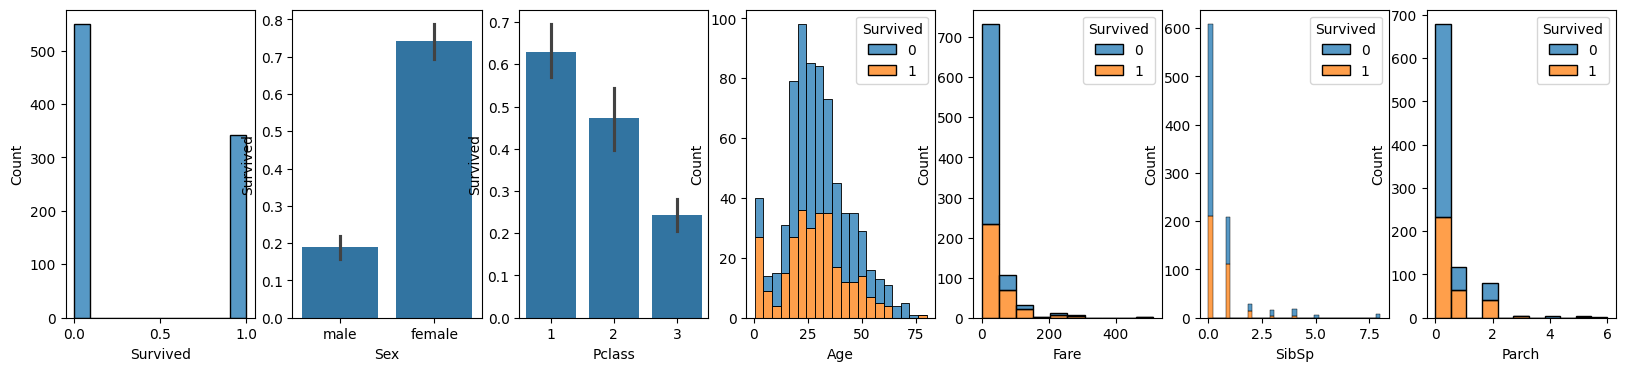

In [13]:
fig, axes = plt.subplots(1, 7, figsize=(20, 4))
sns.histplot(data = df , x = "Survived" , ax = axes[0])
sns.barplot(data = df , x = "Sex",y="Survived", ax = axes[1])
sns.barplot(data=df,x="Pclass",y="Survived",ax = axes[2])
sns.histplot(data=df, x="Age", hue="Survived",multiple="stack", ax =axes[3])
sns.histplot(data=df, x="Fare", hue="Survived",multiple="stack", ax =axes[4],bins = 10)
sns.histplot(data=df, x="SibSp", hue="Survived",multiple="stack", ax =axes[5])
sns.histplot(data=df, x="Parch", hue="Survived", multiple="stack",ax =axes[6])

# Handle missing values using appropriate imputation strategies

In [14]:
si = SimpleImputer(strategy="median")
df["Age"] = si.fit_transform(df[["Age"]])
df = df.drop(columns =["Cabin"])
si = SimpleImputer(strategy="most_frequent")
df["Embarked"] = pd.DataFrame(si.fit_transform(df[["Embarked"]]),columns=["Embarked"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
print(df["Title"].value_counts())
df.drop(columns=["PassengerId","Name","Ticket","SibSp","Parch"],inplace = True)
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}
df["Title"] = df["Title"].replace(title_mapping)
main_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df.loc[~df["Title"].isin(main_titles), "Title"] = "Rare"
print(df["Title"].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Title
Rare    891
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1755/993125255.py:2: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
